In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 

In [2]:
metadata = pd.read_csv('HAM10000_metadata.csv')

In [3]:
metadata.sample(5)

,lesion_id,image_id,dx,dx_type,age,sex,localization
8697,HAM_0004127,ISIC_0031700,nv,histo,55.0,male,back
6476,HAM_0007352,ISIC_0029739,nv,follow_up,40.0,female,lower extremity
414,HAM_0005546,ISIC_0029519,bkl,histo,60.0,male,back
2333,HAM_0004765,ISIC_0025599,vasc,histo,15.0,male,face
6790,HAM_0004318,ISIC_0031678,nv,histo,45.0,female,back


In [4]:
metadata['dx'].value_counts()

dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64

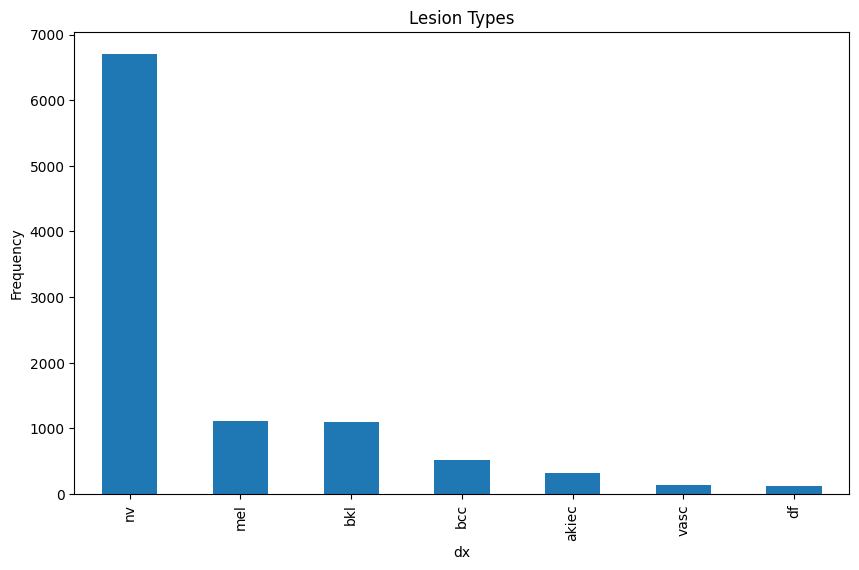

In [5]:
plt.figure(figsize=(10,6))
metadata['dx'].value_counts().plot(kind='bar')
plt.title("Lesion Types")
plt.ylabel("Frequency")
plt.show()

In [6]:
metadata.iloc[1]

lesion_id        HAM_0000118
image_id        ISIC_0025030
dx                       bkl
dx_type                histo
age                     80.0
sex                     male
localization           scalp
Name: 1, dtype: object

In [7]:
image_id1 = metadata.iloc[1]['image_id']

In [8]:
image_id1

'ISIC_0025030'

In [9]:
import os 
from PIL import Image

In [10]:
image_id1_path = os.path.join('HAM10000_images_part_1/', f'{image_id1}.jpg')

In [11]:
image_1 = Image.open(image_id1_path)

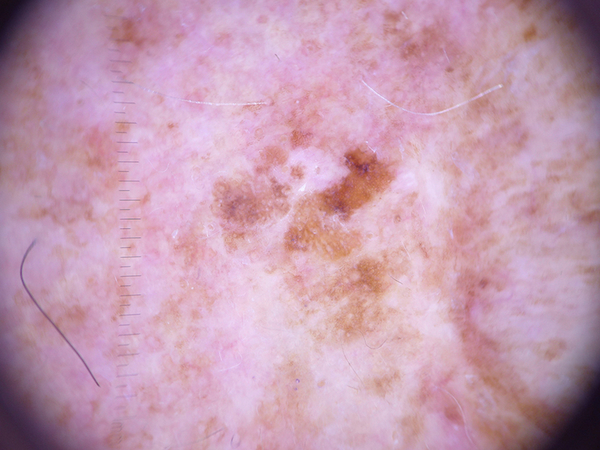

In [12]:
image_1

In [13]:
import torchvision.transforms.v2 as T

In [14]:
tranform = T.Compose([
    T.RandomRotation(20), 
    T.RandomHorizontalFlip(p=0.4), 
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.Resize((224,224)), 
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

C:\Users\Tarun V\Desktop\DS\env\Lib\site-packages\torchvision\transforms\v2\_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [15]:
tranform(image_1)

tensor([[[-1.8782, -1.5528, -1.4843,  ..., -1.9124, -1.9124, -1.9124],
         [-1.8782, -1.5528, -1.4672,  ..., -1.3130, -1.3302, -1.3473],
         [-1.8268, -1.5185, -1.4672,  ..., -0.7479, -0.7650, -0.7822],
         ...,
         [-0.7308, -0.6965, -0.6794,  ..., -1.4500, -1.5014, -1.8268],
         [-1.2959, -1.2959, -1.2788,  ..., -1.4500, -1.5528, -1.8782],
         [-1.9124, -1.9124, -1.9124,  ..., -1.4672, -1.5528, -1.8782]],

        [[-1.8081, -1.6155, -1.5630,  ..., -1.8256, -1.8256, -1.8256],
         [-1.8081, -1.6155, -1.5805,  ..., -1.4405, -1.4580, -1.4580],
         [-1.7731, -1.6155, -1.5630,  ..., -1.0728, -1.0903, -1.1253],
         ...,
         [-1.0728, -1.0553, -1.0203,  ..., -1.5630, -1.5805, -1.7731],
         [-1.4405, -1.4405, -1.4230,  ..., -1.5630, -1.6155, -1.8081],
         [-1.8256, -1.8256, -1.8256,  ..., -1.5630, -1.6506, -1.8081]],

        [[-1.5604, -1.2467, -1.1596,  ..., -1.5953, -1.5953, -1.5953],
         [-1.5604, -1.2293, -1.1596,  ..., -0

In [16]:
metadata['dx'].value_counts()

dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64

In [17]:
label = {'nv' : 0, 'mel' : 1, 'bkl' : 2, 'bcc' : 3, 'akiec' : 4, 'vasc' : 5, 'df' : 6}

In [18]:
metadata['dx'] = metadata['dx'].map(label)

In [19]:
import torch

In [20]:
class CustomDataSetLoader(torch.utils.data.Dataset): 
    def __init__(self, metadata, img_dir, transform = None, target_transform = None): 
        self.metadata = metadata 
        self.img_dir = img_dir
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self): 
        return len(self.metadata)

    def __getitem__(self, idx): 
        img_id = self.metadata.iloc[idx]['image_id']
        if os.path.exists(os.path.join(self.img_dir + "_1", img_id + ".jpg")): 
            img_path = os.path.join(self.img_dir +"_1", img_id + ".jpg")
        else: 
            img_path = os.path.join(self.img_dir +"_2", img_id + ".jpg")

        image = Image.open(img_path)
        label = int(self.metadata.iloc[idx]['dx'])
        if self.transform: 
            image = self.transform(image) 
        if self.target_transform: 
            label = self.target_transform(label)

        return image, label

In [169]:
image_loader = CustomDataSetLoader(metadata, 'HAM10000_images_part', transform=tranform)

In [22]:
image1, label1 = image_loader[1]

In [23]:
image1

tensor([[[-1.9809, -1.9809, -1.9809,  ..., -1.9809, -1.9809, -1.9809],
         [-1.9809, -1.9809, -1.9809,  ..., -1.9809, -1.9809, -1.9809],
         [-1.9809, -1.9809, -1.9809,  ..., -1.9809, -1.9809, -1.9809],
         ...,
         [-1.9809, -1.9809, -1.9809,  ..., -1.9809, -1.9809, -1.9809],
         [-1.9809, -1.9809, -1.9809,  ..., -1.9809, -1.9809, -1.9809],
         [-1.9809, -1.9809, -1.9809,  ..., -1.9809, -1.9809, -1.9809]],

        [[-1.8957, -1.8957, -1.8957,  ..., -1.8957, -1.8957, -1.8957],
         [-1.8957, -1.8957, -1.8957,  ..., -1.8957, -1.8957, -1.8957],
         [-1.8957, -1.8957, -1.8957,  ..., -1.8957, -1.8957, -1.8957],
         ...,
         [-1.8957, -1.8957, -1.8957,  ..., -1.8957, -1.8957, -1.8957],
         [-1.8957, -1.8957, -1.8957,  ..., -1.8957, -1.8957, -1.8957],
         [-1.8957, -1.8957, -1.8957,  ..., -1.8957, -1.8957, -1.8957]],

        [[-1.6650, -1.6650, -1.6650,  ..., -1.6650, -1.6650, -1.6650],
         [-1.6650, -1.6650, -1.6650,  ..., -1

In [24]:
label1

2

In [25]:
images, labels = image_loader[0]

In [26]:
images.shape

torch.Size([3, 224, 224])

In [27]:
from torch.utils.data import DataLoader

In [28]:
from sklearn.model_selection import train_test_split

In [29]:
train_df, temp_df = train_test_split(metadata, test_size=0.3, stratify=metadata['dx'], random_state=42)

val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['dx'], random_state=42)

In [30]:
val_transform = T.Compose([
    T.Resize((224,224)), 
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

C:\Users\Tarun V\Desktop\DS\env\Lib\site-packages\torchvision\transforms\v2\_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [31]:
train_df_loader = CustomDataSetLoader(train_df, 'HAM10000_images_part', transform=tranform)

In [32]:
test_df_loader = CustomDataSetLoader(test_df, 'HAM10000_images_part', transform=val_transform)

In [33]:
val_df_loader = CustomDataSetLoader(val_df, 'HAM10000_images_part', transform=val_transform)

In [34]:
torch.manual_seed(42)
train_loader = DataLoader(train_df_loader, batch_size=32, shuffle=True, pin_memory=True)
valid_loader = DataLoader(val_df_loader, batch_size=32)
test_loader = DataLoader(test_df_loader, batch_size=32)

In [35]:
images, labels = next(iter(train_loader))
print(f"Batch shape: {images.shape}, Labels shape: {labels.shape}")

Batch shape: torch.Size([32, 3, 224, 224]), Labels shape: torch.Size([32])


In [36]:
import torchvision

In [37]:
weights = torchvision.models.ResNet18_Weights.IMAGENET1K_V1

In [38]:
device = 'cuda'

In [39]:
model = torchvision.models.resnet18(weights=weights).to(device)

In [40]:
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [41]:
transform = weights.transforms()

In [42]:
[name for name, child in model.named_children()]

['conv1',
 'bn1',
 'relu',
 'maxpool',
 'layer1',
 'layer2',
 'layer3',
 'layer4',
 'avgpool',
 'fc']

In [43]:
model.fc

Linear(in_features=512, out_features=1000, bias=True)

In [44]:
for param in model.parameters(): 
    param.requires_grad = False 

for param in model.fc.parameters():
    param.requires_grad = True

In [45]:
import torch.nn as nn

In [46]:
model.fc = nn.Linear(in_features=512, out_features=7, bias=True).to(device)

In [47]:
model.fc

Linear(in_features=512, out_features=7, bias=True)

In [48]:
import torchmetrics

def evaluate_tm(model, data_loader, metric): 
    model.eval()
    metric.reset()
    with torch.no_grad(): 
        for X_batch, y_batch in data_loader: 
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            metric.update(y_pred, y_batch)

    return metric.compute()


def train(model, optimizer, loss_fn, metric, train_loader, valid_loader, n_epochs): 
    history = {"train_losses" : [], "train_metrics" : [], "valid_metrics" : []}
    for epoch in range(n_epochs):
        total_loss = 0
        metric.reset()
        model.train()
        for X_batch, y_batch in train_loader: 
            X_batch, y_batch = X_batch.to(device), y_batch.to(device) 
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)
        history["train_losses"].append(total_loss / len(train_loader))
        history["train_metrics"].append(metric.compute().item())
        history["valid_metrics"].append(evaluate_tm(model, valid_loader, metric).item())

        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train metric: {history['train_metrics'][-1]:.4f}, "
              f"valid metric: {history['valid_metrics'][-1]:.4f}")
    return history

In [49]:
class_counts = train_df['dx'].value_counts().sort_index().values
class_weights = 1.0 / torch.tensor(class_counts, dtype=torch.float)
class_weights = class_weights / class_weights.sum() * len(class_weights)

print(f"Class weights: {class_weights}")

Class weights: tensor([0.0461, 0.2774, 0.2810, 0.6004, 0.9438, 2.1831, 2.6682])


In [50]:
n_epochs = 10
trainable_params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(trainable_params, lr=1e-4)
xentropy = nn.CrossEntropyLoss(weight=class_weights.to(device))
accuracy = torchmetrics.Accuracy(task="multiclass",
                                 num_classes=7).to(device)
history = train(model, optimizer, xentropy, accuracy,
                train_loader, valid_loader, n_epochs)

Epoch 1/10, train loss: 1.9133, train metric: 0.3488, valid metric: 0.3495
Epoch 2/10, train loss: 1.7410, train metric: 0.5081, valid metric: 0.4587
Epoch 3/10, train loss: 1.6299, train metric: 0.5478, valid metric: 0.5479
Epoch 4/10, train loss: 1.5423, train metric: 0.5789, valid metric: 0.5413
Epoch 5/10, train loss: 1.4748, train metric: 0.5853, valid metric: 0.5126
Epoch 6/10, train loss: 1.4303, train metric: 0.5940, valid metric: 0.5333
Epoch 7/10, train loss: 1.3993, train metric: 0.6057, valid metric: 0.5672
Epoch 8/10, train loss: 1.3517, train metric: 0.6137, valid metric: 0.5466
Epoch 9/10, train loss: 1.3243, train metric: 0.6168, valid metric: 0.5652
Epoch 10/10, train loss: 1.3001, train metric: 0.6240, valid metric: 0.5832


In [51]:
class_weights

tensor([0.0461, 0.2774, 0.2810, 0.6004, 0.9438, 2.1831, 2.6682])

In [52]:
[name for name, child in model.named_children()]

['conv1',
 'bn1',
 'relu',
 'maxpool',
 'layer1',
 'layer2',
 'layer3',
 'layer4',
 'avgpool',
 'fc']

In [53]:
for param in model.parameters(): 
    param.requires_grad = False 

for param in model.layer4.parameters(): 
    param.requires_grad = True

for param in model.layer3.parameters(): 
    param.requires_grad = True

for param in model.fc.parameters(): 
    param.requires_grad = True

In [55]:
n_epochs = 10
trainable_params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(trainable_params, lr=1e-5)
xentropy = nn.CrossEntropyLoss(weight=class_weights.to(device))
accuracy = torchmetrics.Accuracy(task="multiclass",
                                 num_classes=7).to(device)
history = train(model, optimizer, xentropy, accuracy,
                train_loader, valid_loader, n_epochs)

Epoch 1/10, train loss: 1.1496, train metric: 0.6311, valid metric: 0.6045
Epoch 2/10, train loss: 0.9432, train metric: 0.6635, valid metric: 0.6385
Epoch 3/10, train loss: 0.8217, train metric: 0.6974, valid metric: 0.6744
Epoch 4/10, train loss: 0.7327, train metric: 0.7173, valid metric: 0.6605
Epoch 5/10, train loss: 0.6804, train metric: 0.7324, valid metric: 0.6924
Epoch 6/10, train loss: 0.6319, train metric: 0.7419, valid metric: 0.6778
Epoch 7/10, train loss: 0.5808, train metric: 0.7583, valid metric: 0.7071
Epoch 8/10, train loss: 0.5603, train metric: 0.7675, valid metric: 0.7164
Epoch 9/10, train loss: 0.5013, train metric: 0.7730, valid metric: 0.7164
Epoch 10/10, train loss: 0.4659, train metric: 0.7987, valid metric: 0.7290


In [56]:
for param in model.parameters(): 
    param.requires_grad = False 

for param in model.fc.parameters(): 
    param.requires_grad = True

In [57]:
n_epochs = 5
trainable_params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(trainable_params, lr=1e-5)
xentropy = nn.CrossEntropyLoss(weight=class_weights.to(device))
accuracy = torchmetrics.Accuracy(task="multiclass",
                                 num_classes=7).to(device)
history = train(model, optimizer, xentropy, accuracy,
                train_loader, valid_loader, n_epochs)

Epoch 1/5, train loss: 0.4439, train metric: 0.7971, valid metric: 0.7057
Epoch 2/5, train loss: 0.4332, train metric: 0.8011, valid metric: 0.7244
Epoch 3/5, train loss: 0.4247, train metric: 0.8017, valid metric: 0.7144
Epoch 4/5, train loss: 0.4411, train metric: 0.8010, valid metric: 0.7310
Epoch 5/5, train loss: 0.4265, train metric: 0.8031, valid metric: 0.7164


In [58]:
for param in model.parameters(): 
    param.requires_grad = False 

for param in model.layer4.parameters(): 
    param.requires_grad = True

for param in model.layer3.parameters(): 
    param.requires_grad = True

for param in model.fc.parameters(): 
    param.requires_grad = True

In [59]:
n_epochs = 5
trainable_params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(trainable_params, lr=1e-5)
xentropy = nn.CrossEntropyLoss(weight=class_weights.to(device))
accuracy = torchmetrics.Accuracy(task="multiclass",
                                 num_classes=7).to(device)
history = train(model, optimizer, xentropy, accuracy,
                train_loader, valid_loader, n_epochs)

Epoch 1/5, train loss: 0.4564, train metric: 0.7944, valid metric: 0.7403
Epoch 2/5, train loss: 0.4263, train metric: 0.7993, valid metric: 0.7410
Epoch 3/5, train loss: 0.3984, train metric: 0.8037, valid metric: 0.7364
Epoch 4/5, train loss: 0.3641, train metric: 0.8133, valid metric: 0.7430
Epoch 5/5, train loss: 0.3558, train metric: 0.8278, valid metric: 0.7477


In [60]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, confusion_matrix

In [77]:
model.eval()
y_pred = []
y_true = [] 

with torch.no_grad(): 
    for images, labels in valid_loader: 
        images = images.to(device) 
        pred = model(images)
        pred = pred.argmax(axis=1).cpu()
        y_pred.append(pred.numpy())
        y_true.append(labels.numpy())

In [78]:
y_pred

[array([0, 1, 0, 1, 1, 0, 1, 0, 3, 4, 2, 0, 2, 4, 0, 0, 0, 1, 0, 1, 1, 0,
        1, 1, 2, 0, 0, 0, 2, 0, 2, 0]),
 array([1, 6, 3, 3, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 4, 0,
        0, 5, 0, 5, 0, 1, 0, 0, 6, 0]),
 array([3, 1, 2, 0, 3, 0, 0, 0, 0, 0, 0, 0, 3, 1, 3, 0, 0, 1, 1, 0, 4, 1,
        0, 0, 0, 0, 2, 0, 1, 0, 0, 1]),
 array([0, 0, 1, 0, 2, 0, 2, 1, 0, 0, 0, 0, 0, 3, 0, 0, 0, 5, 3, 0, 0, 1,
        1, 1, 0, 0, 0, 0, 0, 0, 4, 0]),
 array([0, 3, 4, 0, 6, 0, 3, 0, 0, 5, 5, 0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 1,
        0, 1, 0, 0, 2, 0, 3, 0, 1, 0]),
 array([2, 6, 0, 0, 0, 2, 6, 3, 1, 0, 1, 0, 2, 0, 0, 1, 0, 1, 0, 3, 1, 3,
        1, 1, 1, 3, 0, 1, 1, 1, 0, 0]),
 array([2, 0, 0, 2, 0, 0, 0, 0, 0, 3, 0, 1, 0, 0, 2, 0, 0, 0, 0, 3, 0, 1,
        1, 1, 2, 0, 0, 0, 2, 0, 0, 0]),
 array([3, 0, 0, 0, 3, 5, 0, 2, 0, 3, 1, 2, 0, 0, 2, 0, 3, 0, 0, 0, 0, 0,
        0, 1, 5, 0, 0, 0, 0, 2, 6, 0]),
 array([0, 0, 0, 6, 0, 0, 0, 0, 3, 3, 0, 0, 0, 0, 2, 1, 0, 2, 2, 1, 1, 0,
        0, 4, 

In [80]:
y_true

[array([0, 2, 0, 0, 1, 0, 1, 0, 4, 2, 1, 0, 2, 4, 0, 0, 0, 1, 0, 0, 0, 0,
        1, 1, 0, 0, 0, 0, 2, 0, 2, 0]),
 array([0, 6, 0, 4, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 2, 0,
        0, 2, 0, 5, 0, 2, 0, 0, 6, 0]),
 array([3, 0, 1, 0, 3, 0, 0, 0, 0, 0, 0, 0, 2, 1, 3, 0, 0, 1, 0, 0, 4, 0,
        0, 0, 0, 0, 2, 0, 1, 0, 0, 1]),
 array([0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 5, 3, 0, 0, 3,
        0, 4, 0, 0, 0, 0, 0, 0, 4, 0]),
 array([0, 4, 4, 0, 2, 0, 3, 0, 0, 5, 5, 1, 0, 0, 0, 0, 3, 0, 0, 0, 0, 0,
        0, 2, 0, 0, 0, 0, 0, 0, 0, 0]),
 array([2, 6, 0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 3,
        0, 1, 1, 0, 0, 1, 1, 0, 0, 0]),
 array([2, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 1, 0, 0, 2, 0, 0, 0, 0, 3, 0, 1,
        0, 1, 2, 0, 0, 0, 2, 0, 0, 0]),
 array([3, 0, 0, 0, 3, 5, 0, 2, 0, 3, 2, 1, 0, 0, 2, 0, 3, 0, 0, 0, 0, 0,
        0, 0, 5, 0, 0, 0, 0, 2, 0, 0]),
 array([2, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 2, 0, 0, 2, 4, 0, 0, 0,
        0, 4, 

In [83]:
y_pred_1 = [item for sublist in y_pred for item in sublist]
y_true_1 = [item for sublist in y_true for item in sublist]

In [85]:
precision_score(y_true_1, y_pred_1, average= None)

array([0.96641791, 0.40282686, 0.61714286, 0.53225806, 0.51785714,
       0.56666667, 0.4       ])

In [87]:
recall_score(y_true_1, y_pred_1, average=None)

array([0.77236581, 0.68263473, 0.65454545, 0.85714286, 0.59183673,
       0.80952381, 0.70588235])

In [88]:
f1_score(y_true_1, y_pred_1, average=None)

array([0.85856354, 0.50666667, 0.63529412, 0.65671642, 0.55238095,
       0.66666667, 0.5106383 ])

In [110]:
cm = confusion_matrix(y_true_1,y_pred_1,normalize='true')
cm

array([[0.77236581, 0.13220676, 0.04274354, 0.027833  , 0.00497018,
        0.00795229, 0.01192843],
       [0.11976048, 0.68263473, 0.10179641, 0.05389222, 0.03592814,
        0.        , 0.00598802],
       [0.03030303, 0.15151515, 0.65454545, 0.04848485, 0.07878788,
        0.01212121, 0.02424242],
       [0.        , 0.05194805, 0.01298701, 0.85714286, 0.03896104,
        0.03896104, 0.        ],
       [0.        , 0.10204082, 0.08163265, 0.20408163, 0.59183673,
        0.        , 0.02040816],
       [0.0952381 , 0.        , 0.04761905, 0.04761905, 0.        ,
        0.80952381, 0.        ],
       [0.        , 0.11764706, 0.05882353, 0.11764706, 0.        ,
        0.        , 0.70588235]])

In [111]:
print(classification_report(y_true_1, y_pred_1, target_names=['nv','mel' ,'bkl','bcc','akiec','vasc','df']))

              precision    recall  f1-score   support

          nv       0.97      0.77      0.86      1006
         mel       0.40      0.68      0.51       167
         bkl       0.62      0.65      0.64       165
         bcc       0.53      0.86      0.66        77
       akiec       0.52      0.59      0.55        49
        vasc       0.57      0.81      0.67        21
          df       0.40      0.71      0.51        17

    accuracy                           0.75      1502
   macro avg       0.57      0.72      0.63      1502
weighted avg       0.82      0.75      0.77      1502



In [97]:
from sklearn.metrics import ConfusionMatrixDisplay

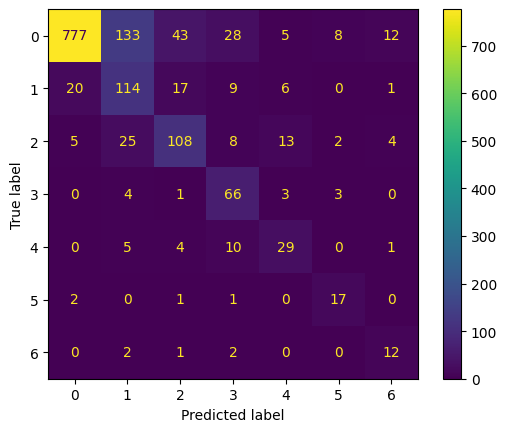

In [115]:
ConfusionMatrixDisplay(confusion_matrix(y_true_1, y_pred_1)).plot();

Even After adjusting for class imbalace , many predictions are going towards 0, due to the large number instances present for that class.

many of the label1 predictions going to awards label 2, they must be similer in images.

Other  than that Overall Everything Seems to Be Similer, many misclassificatios seem to be same percenatge as other

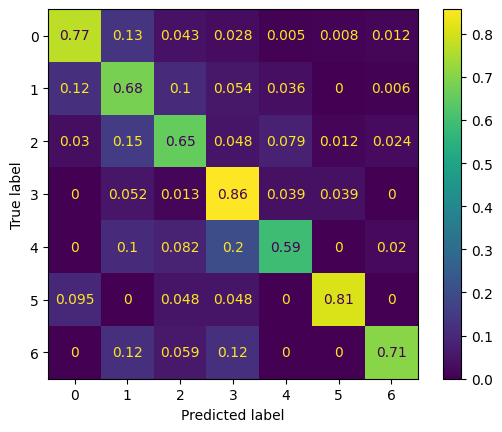

In [116]:
ConfusionMatrixDisplay(cm).plot();

added normalization, 
* We Can Now See That label 3 and 5 are doing great in predicting those, meaning it as high recall 
* We Can Also See that label 4 is the least confident or its not predicting thise correctly , perhaps hadding more weight to it would help
* We Can Also see the label 1 which is melonama is not doing great its wrongly classifying itself more with labeel 0 and 2
* we can also many others like those like label 4 15% misclassified as label 3, so the images are similer and weights should be adjusted
* and we can also obersve that label 0 which as a lot of instances are getting wrongly classified, due to class weight being so low and when other models nott confident they predict label 0

In [117]:
class_weights

tensor([0.0461, 0.2774, 0.2810, 0.6004, 0.9438, 2.1831, 2.6682])

In [118]:
from sklearn.utils.class_weight import compute_class_weight

In [131]:
class_weights_1 = compute_class_weight('balanced', classes=np.unique(metadata['dx']), y=metadata['dx'])
class_weights_1 = torch.Tensor(class_weights_1)
class_weights_1

tensor([ 0.2134,  1.2855,  1.3018,  2.7835,  4.3753, 10.0755, 12.4410])

In [124]:
n_epochs = 5
trainable_params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(trainable_params, lr=1e-5)
xentropy = nn.CrossEntropyLoss(weight=class_weights_1.to(device))
accuracy = torchmetrics.Accuracy(task="multiclass",
                                 num_classes=7).to(device)
history = train(model, optimizer, xentropy, accuracy,
                train_loader, valid_loader, n_epochs)

Epoch 1/5, train loss: 0.3290, train metric: 0.8272, valid metric: 0.7443
Epoch 2/5, train loss: 0.3074, train metric: 0.8454, valid metric: 0.7583
Epoch 3/5, train loss: 0.2861, train metric: 0.8455, valid metric: 0.7843
Epoch 4/5, train loss: 0.2910, train metric: 0.8509, valid metric: 0.7696
Epoch 5/5, train loss: 0.2567, train metric: 0.8569, valid metric: 0.7630


In [125]:
model.eval()
y_pred = []
y_true = [] 

with torch.no_grad(): 
    for images, labels in valid_loader: 
        images = images.to(device) 
        pred = model(images)
        pred = pred.argmax(axis=1).cpu()
        y_pred.append(pred.numpy())
        y_true.append(labels.numpy())

In [126]:
y_pred_2 = [item for sublist in y_pred for item in sublist]
y_true_2 = [item for sublist in y_true for item in sublist]

In [127]:
print(classification_report(y_true_2, y_pred_2, target_names=['nv','mel' ,'bkl','bcc','akiec','vasc','df']))

              precision    recall  f1-score   support

          nv       0.96      0.78      0.86      1006
         mel       0.39      0.76      0.51       167
         bkl       0.64      0.70      0.67       165
         bcc       0.72      0.74      0.73        77
       akiec       0.60      0.67      0.63        49
        vasc       0.61      0.81      0.69        21
          df       0.69      0.53      0.60        17

    accuracy                           0.76      1502
   macro avg       0.66      0.71      0.67      1502
weighted avg       0.83      0.76      0.78      1502



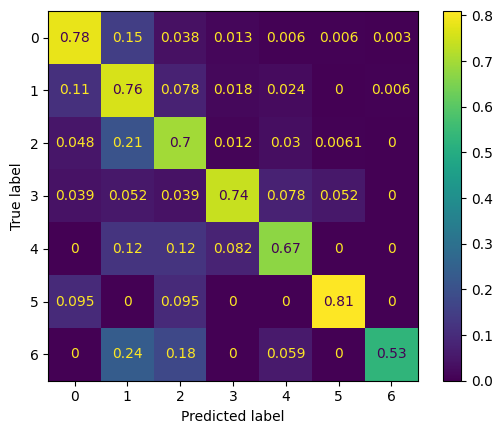

In [128]:
ConfusionMatrixDisplay(confusion_matrix(y_true_2, y_pred_2, normalize='true')).plot();

"Increasing class weights doesn't always help that class"
Class 6 is proof:

Weight went up 4.6x
Performance went DOWN 18

The Melanoma Improvement (Most Important)
Class 1 (mel) recall: 0.68 → 0.76 (+8%)
But look at precision:

Before: 0.40 (from your first report)
After: 0.39 (from this report)

What does this mean?

Recall up = catching more melanomas ✓
Precision down = more false alarms ❌

For medical use: Is this tradeoff acceptable?

8% more melanomas caught
But slightly more false positives

Hint: In cancer screening, this might be good - better to have false alarms than miss cancer

I evaluated two class weighting strategies:

Model A (Conservative): 75% accuracy, 68% melanoma recall
Model B (Aggressive): 76% accuracy, 76% melanoma recall

I selected Model B despite worse performance on BCC (74%→86%) 
and DF (71%→53%) for the following clinical reasons:

1. Melanoma is rapidly metastatic and requires early detection
2. The 8% improvement in melanoma recall (68%→76%) translates 
   to ~13 additional melanoma cases caught in this test set
3. BCC, while cancerous, is slow-growing and the 12% recall drop 
   is acceptable given its lower lethality
4. DF is benign, so reduced performance is clinically acceptable

Tradeoff Analysis:
- False negatives for melanoma: 32% → 24% (CRITICAL improvement)
- False negatives for BCC: 14% → 26% (acceptable given lower urgency)

This prioritization aligns with standard oncology practice 
where melanoma screening is treated with highest urgency.

In [178]:
class CustomDataSetLoader11(torch.utils.data.Dataset): 
    def __init__(self, metadata, img_dir, transform = None, target_transform = None): 
        self.metadata = metadata 
        self.img_dir = img_dir
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self): 
        return len(self.metadata)

    def __getitem__(self, idx): 
        img_id = self.metadata.iloc[idx]['image_id']
        if os.path.exists(os.path.join(self.img_dir + "_1", img_id + ".jpg")): 
            img_path = os.path.join(self.img_dir +"_1", img_id + ".jpg")
        else: 
            img_path = os.path.join(self.img_dir +"_2", img_id + ".jpg")

        image = Image.open(img_path)
        label = int(self.metadata.iloc[idx]['dx'])
        if self.transform: 
            image = self.transform(image) 
        if self.target_transform: 
            label = self.target_transform(label)

        return image, label

In [179]:
vis_loader = CustomDataSetLoader11(metadata, 'HAM10000_images_part')

In [190]:
vis_images = []
for i in range(len(y_pred_2)): 
    if (y_pred_2[i] == 0 and y_true_2[i] == 1).any(): 
        idx = i 
        y = int(valid_loader.dataset.metadata.index[idx])
        vis_image, vis_lable = vis_loader[y]
        vis_images.append(vis_image)

In [246]:
vis_images1 = []
for i in range(len(y_pred_2)): 
    if (y_true_2[i] == 0).any(): 
        idx = i 
        y = int(valid_loader.dataset.metadata.index[idx])
        vis_image1, vis_lables1 = vis_loader[y]
        vis_images1.append(vis_image1)

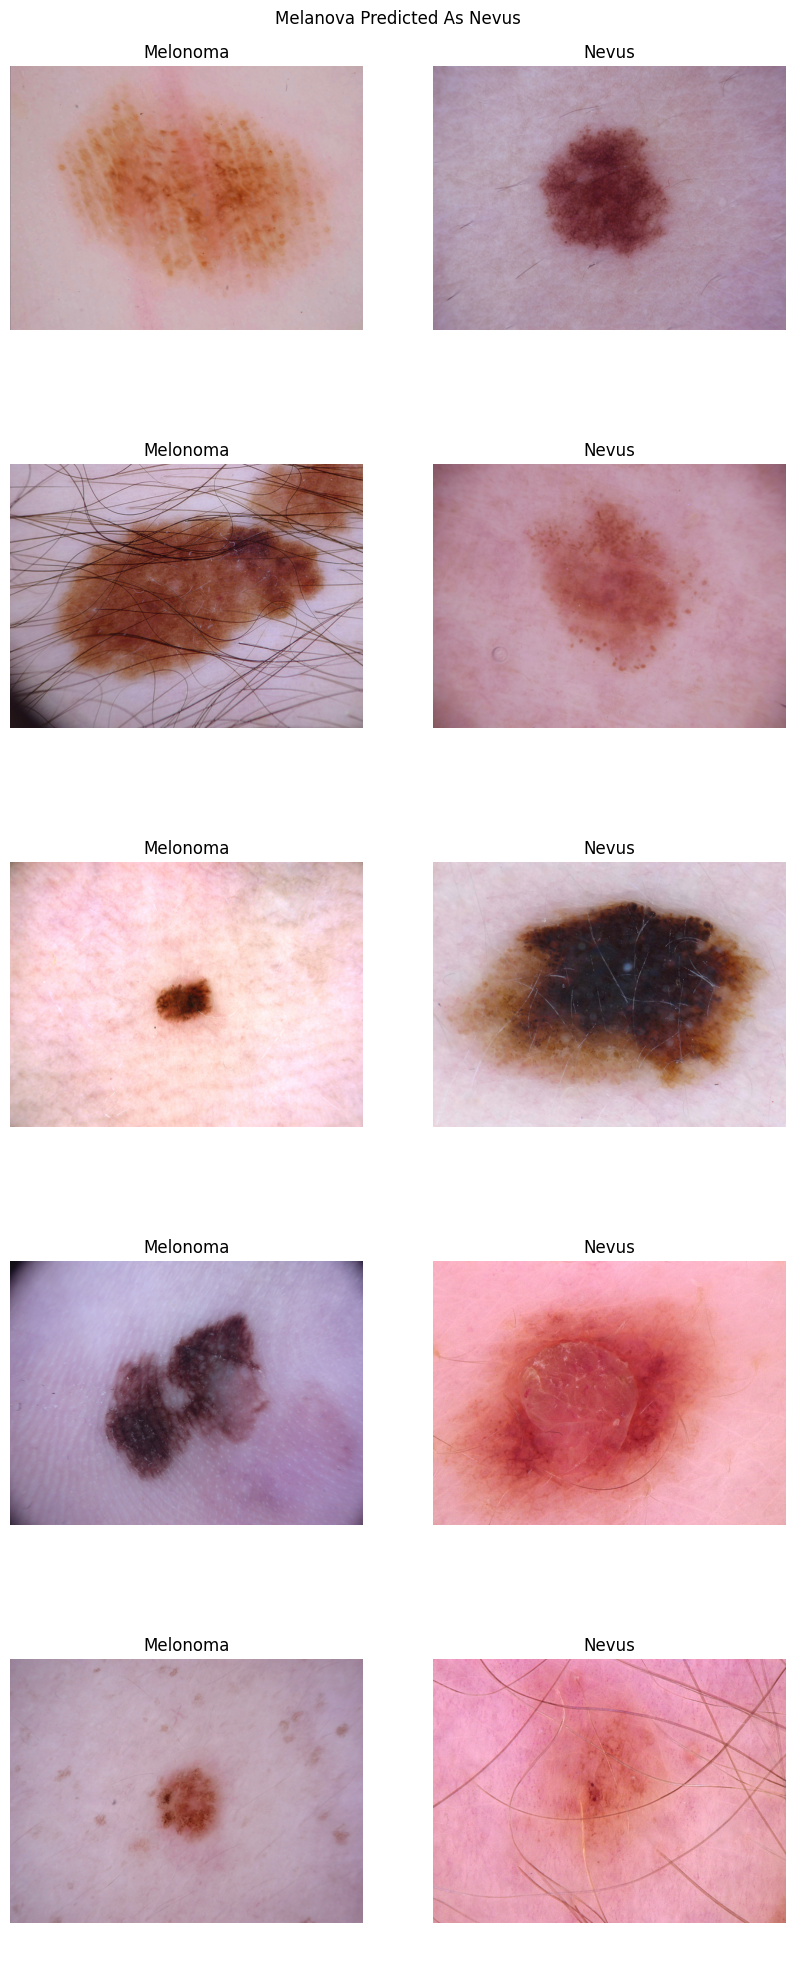

In [247]:
plt.figure(figsize=(10,5*5))
plt.title("Melanova Predicted As Nevus")
plt.axis('off')
for i in range(5): 
    plt.subplot(5,2,2*i + 1)
    plt.imshow(vis_images[i])
    plt.title("Melonoma")
    plt.axis('off')

    plt.subplot(5,2,2*i + 2)
    plt.title("Nevus")
    plt.imshow(vis_images1[i])
    plt.axis('off')

* Although They Dont Look Similer But Still The Predictions Are Classified as Nevus this is mostly because of the large nu,ber of instances present for nevus and the model is not that confident in the prediction
* One Solution To this to reduce the probabilty for predicting melonoma (ex., if pred['melanova'] > 0.3 pred['melonova'] = 1)

In [249]:
vis_images1 = []
for i in range(len(y_pred_2)): 
    if (y_true_2[i] == 1).any(): # Melanoma
        idx = i 
        y = int(valid_loader.dataset.metadata.index[idx])
        vis_image1, vis_lables1 = vis_loader[y]
        vis_images1.append(vis_image1)

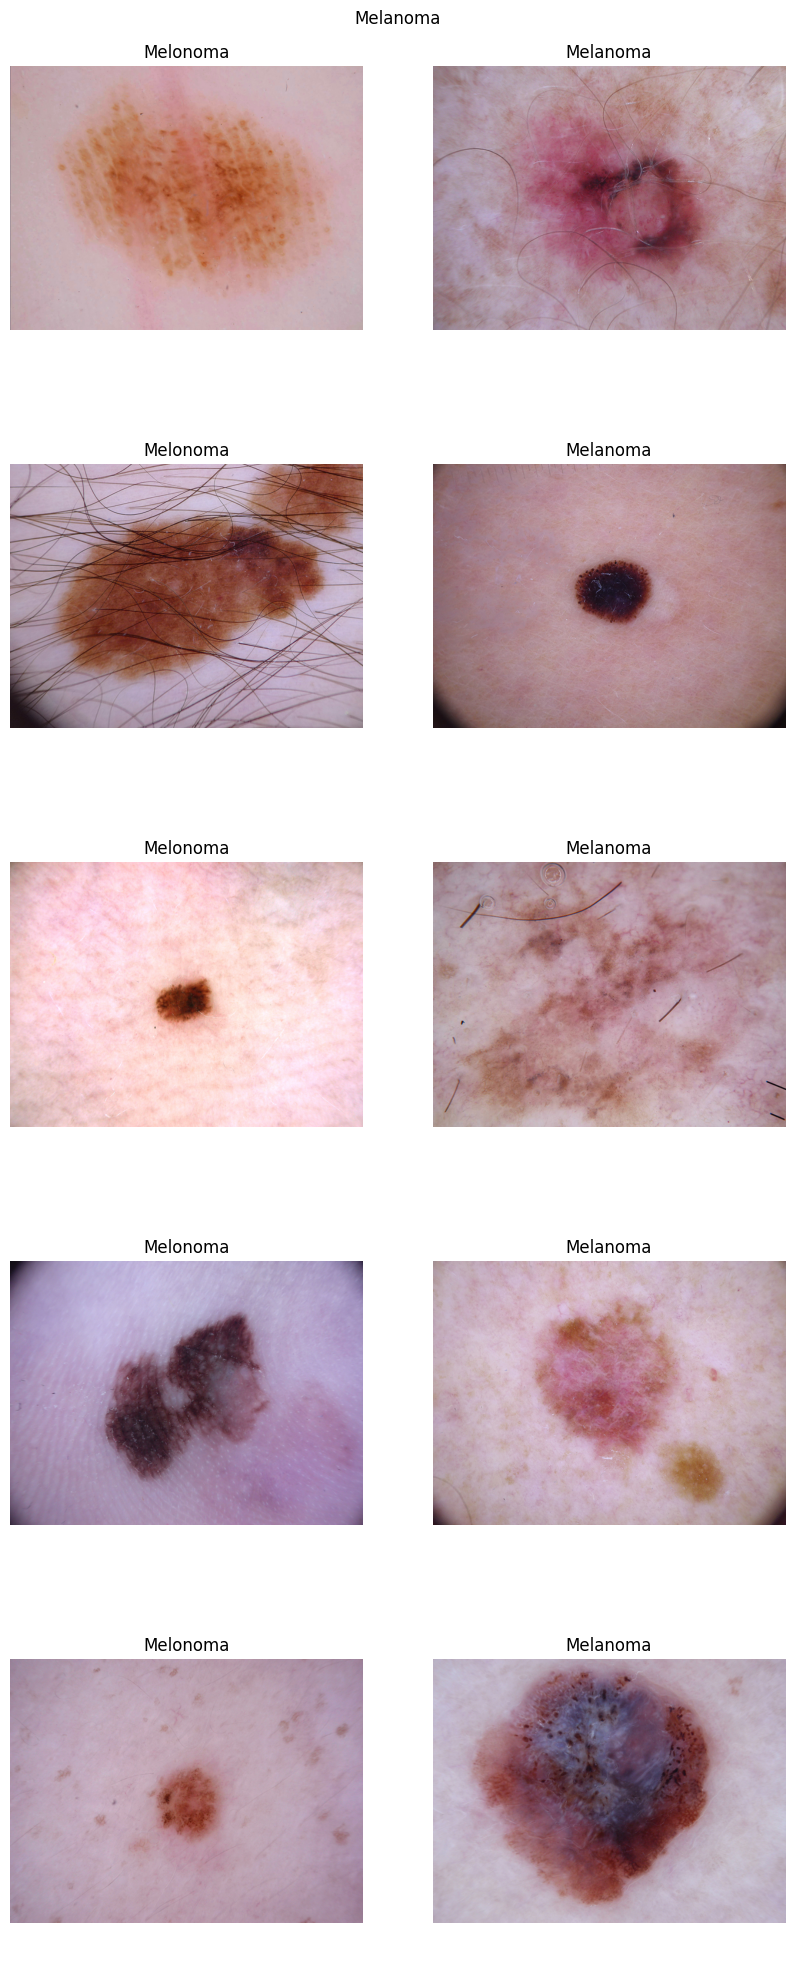

In [250]:
plt.figure(figsize=(10,5*5))
plt.title("Melanoma")
plt.axis('off')
for i in range(5): 
    plt.subplot(5,2,2*i + 1)
    plt.imshow(vis_images[i])
    plt.title("Melonoma")
    plt.axis('off')

    plt.subplot(5,2,2*i + 2)
    plt.title("Melanoma")
    plt.imshow(vis_images1[i])
    plt.axis('off')

## Critical Finding: Model Misses Subtle Melanomas

### Comparison of Correctly vs Incorrectly Classified Melanomas

**Correctly Classified Melanomas (High Confidence):**
- Darker pigmentation
- Larger size
- Clear asymmetry and irregular borders
- Multiple colors present
- Advanced/obvious cases

**Missed Melanomas (Classified as Nevus):**
- Lighter pigmentation (tan/brown vs dark brown/black)
- Smaller lesions
- Less obvious asymmetry
- More uniform appearance
- **Likely early-stage melanomas**

### Clinical Significance

**This is a critical flaw for screening applications:**
- The model performs well on advanced, obvious melanomas that would likely 
  be caught by visual inspection alone
- The model fails on subtle, early-stage melanomas where AI assistance 
  would provide the most value
- Early detection is crucial for melanoma treatment success

**Root Cause:**
The model may be learning "prototypical" melanoma features from the most 
obvious training examples, failing to generalize to the subtle presentation 
spectrum.

##### The Model's Recall And Precision Can Be Improved Using Other High End Pre-Trained Model oR A Pre-trained Model Which Was Trained On Medical Images